In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_squared_error, mean_absolute_error



In [ ]:
path = r"C:\Users\HP\Desktop\AI_project\machine_projects\Used Car Dataset.csv"
df = pd.read_csv(path)
df = pd.DataFrame(df)

In [ ]:
df.head()

,Unnamed: 0,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,0,2017 Mercedes-Benz S-Class S400,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,7.81,2996.0,2996.0,333.0,63.75
1,1,2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.40,999.0,999.0,9863.0,8.99
2,2,2018 BMW X1 sDrive 20d xLine,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,20.68,1995.0,1995.0,188.0,23.75
3,3,2019 Kia Seltos GTX Plus,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,16.50,1353.0,1353.0,13808.0,13.56
4,4,2019 Skoda Superb LK 1.8 TSI AT,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,14.67,1798.0,1798.0,17746.0,24.00


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1553 entries, 0 to 1552
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          1553 non-null   int64  
 1   car_name            1553 non-null   str    
 2   registration_year   1553 non-null   str    
 3   insurance_validity  1553 non-null   str    
 4   fuel_type           1553 non-null   str    
 5   seats               1553 non-null   int64  
 6   kms_driven          1553 non-null   int64  
 7   ownsership          1553 non-null   str    
 8   transmission        1553 non-null   str    
 9   manufacturing_year  1553 non-null   str    
 10  mileage(kmpl)       1550 non-null   float64
 11  engine(cc)          1550 non-null   float64
 12  max_power(bhp)      1550 non-null   float64
 13  torque(Nm)          1549 non-null   float64
 14  price(in lakhs)     1553 non-null   float64
dtypes: float64(5), int64(3), str(7)
memory usage: 182.1 KB


In [ ]:
df.describe()

,Unnamed: 0,seats,kms_driven,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
count,1553.000000,1553.000000,1553.000000,1550.000000,1.550000e+03,1.550000e+03,1.549000e+03,1553.000000
mean,776.000000,91.480361,52841.931101,236.927277,1.471857e+10,1.471857e+10,1.423989e+04,166.141494
std,448.456798,2403.424060,40067.800347,585.964295,2.185629e+11,2.185629e+11,9.666241e+04,3478.855090
min,0.000000,4.000000,620.000000,7.810000,5.000000e+00,5.000000e+00,5.000000e+00,1.000000
25%,388.000000,5.000000,30000.000000,16.342500,1.197000e+03,1.197000e+03,4.000000e+02,4.660000
50%,776.000000,5.000000,49134.000000,18.900000,1.462000e+03,1.462000e+03,1.173000e+03,7.140000
75%,1164.000000,5.000000,70000.000000,22.000000,1.995000e+03,1.995000e+03,8.850000e+03,17.000000
max,1552.000000,67000.000000,810000.000000,3996.000000,3.258640e+12,3.258640e+12,1.464800e+06,95000.000000


In [ ]:
df.isnull().sum()

Unnamed: 0            0
car_name              0
registration_year     0
insurance_validity    0
fuel_type             0
seats                 0
kms_driven            0
ownsership            0
transmission          0
manufacturing_year    0
mileage(kmpl)         3
engine(cc)            3
max_power(bhp)        3
torque(Nm)            4
price(in lakhs)       0
dtype: int64

In [ ]:
df['mileage(kmpl)'] = df['mileage(kmpl)'].fillna(df['mileage(kmpl)']).mean()
df['engine(cc)'] = df['engine(cc)'].fillna(df['engine(cc)']).mean()
df['max_power(bhp)'] = df['max_power(bhp)'].fillna(df['max_power(bhp)']).mean()
df['torque(Nm)'] = df['torque(Nm)'].fillna(df['torque(Nm)']).mean()

In [ ]:
df.isnull().sum()

Unnamed: 0            0
car_name              0
registration_year     0
insurance_validity    0
fuel_type             0
seats                 0
kms_driven            0
ownsership            0
transmission          0
manufacturing_year    0
mileage(kmpl)         0
engine(cc)            0
max_power(bhp)        0
torque(Nm)            0
price(in lakhs)       0
dtype: int64

In [ ]:
df.head()

,Unnamed: 0,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,0,2017 Mercedes-Benz S-Class S400,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,236.927277,1.471857e+10,1.471857e+10,14239.891543,63.75
1,1,2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,236.927277,1.471857e+10,1.471857e+10,14239.891543,8.99
2,2,2018 BMW X1 sDrive 20d xLine,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,236.927277,1.471857e+10,1.471857e+10,14239.891543,23.75
3,3,2019 Kia Seltos GTX Plus,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,236.927277,1.471857e+10,1.471857e+10,14239.891543,13.56
4,4,2019 Skoda Superb LK 1.8 TSI AT,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,236.927277,1.471857e+10,1.471857e+10,14239.891543,24.00


In [ ]:
df.columns

Index(['Unnamed: 0', 'car_name', 'registration_year', 'insurance_validity',
       'fuel_type', 'seats', 'kms_driven', 'ownsership', 'transmission',
       'manufacturing_year', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)',
       'torque(Nm)', 'price(in lakhs)'],
      dtype='str')

In [ ]:
df.dtypes

Unnamed: 0              int64
car_name                  str
registration_year         str
insurance_validity        str
fuel_type                 str
seats                   int64
kms_driven              int64
ownsership                str
transmission              str
manufacturing_year        str
mileage(kmpl)         float64
engine(cc)            float64
max_power(bhp)        float64
torque(Nm)            float64
price(in lakhs)       float64
dtype: object

In [ ]:
numaric_col = ['Unnamed: 0', 'car_name', 'registration_year', 'insurance_validity','fuel_type', 'seats', 'kms_driven', 'ownsership', 'transmission','manufacturing_year', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)','torque(Nm)', 'price(in lakhs)']

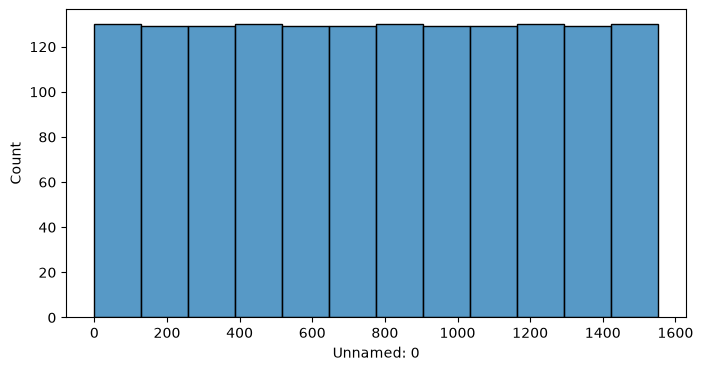

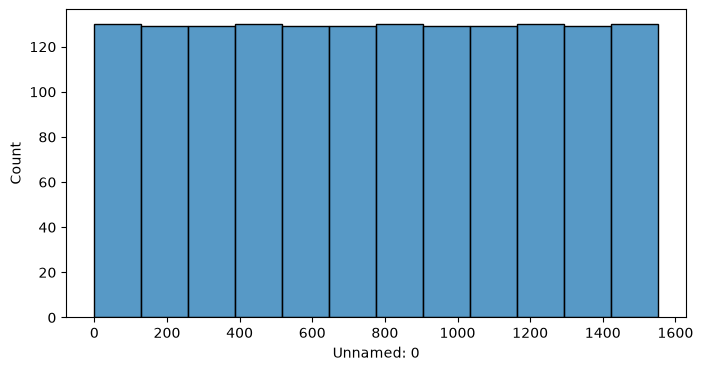

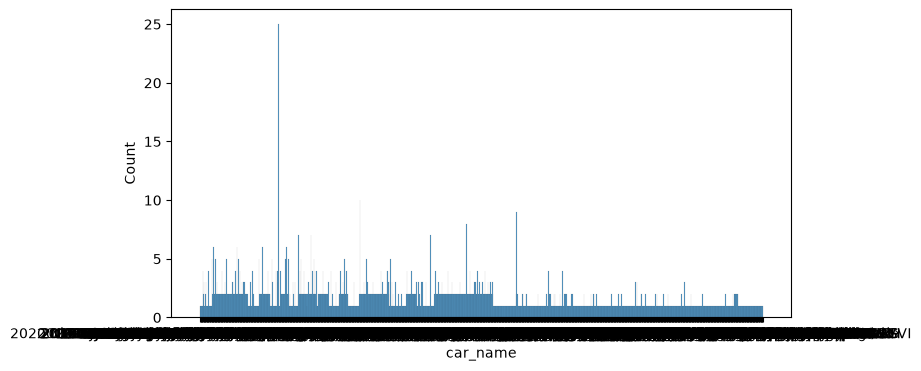

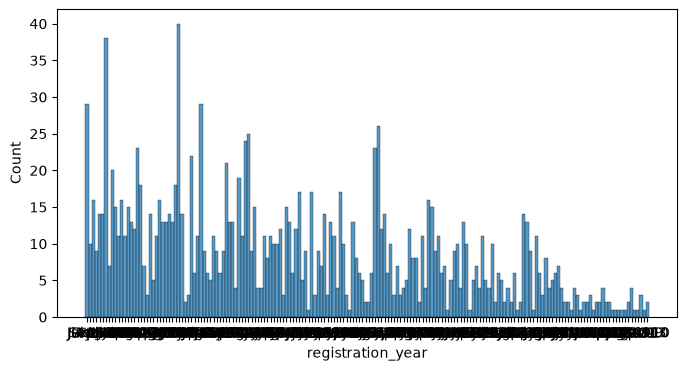

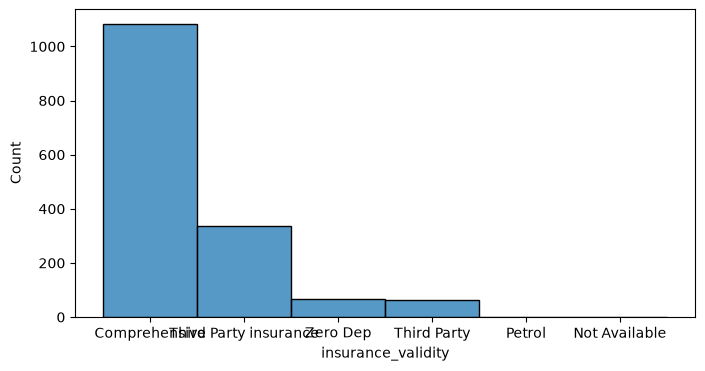

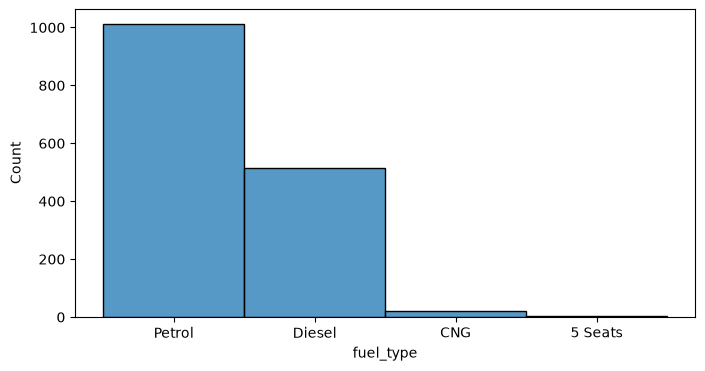

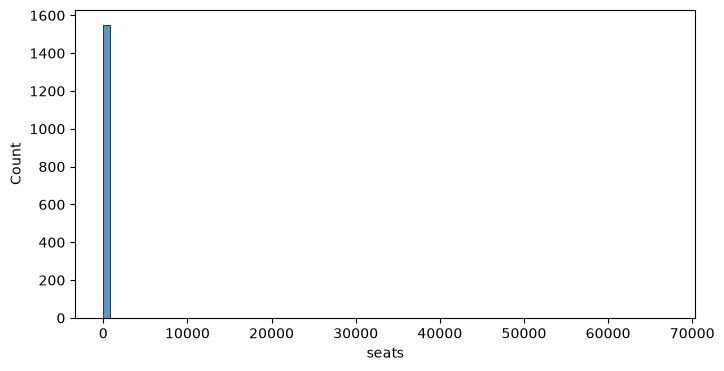

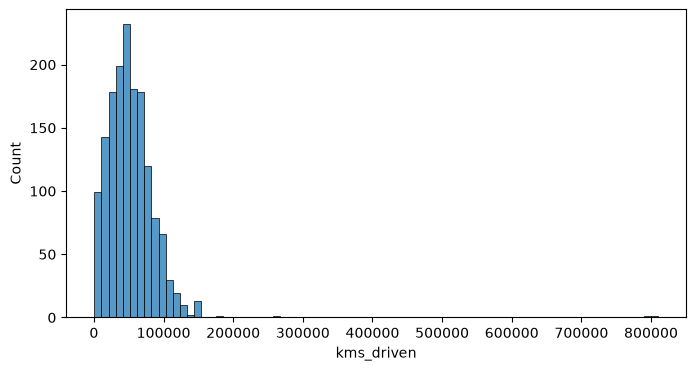

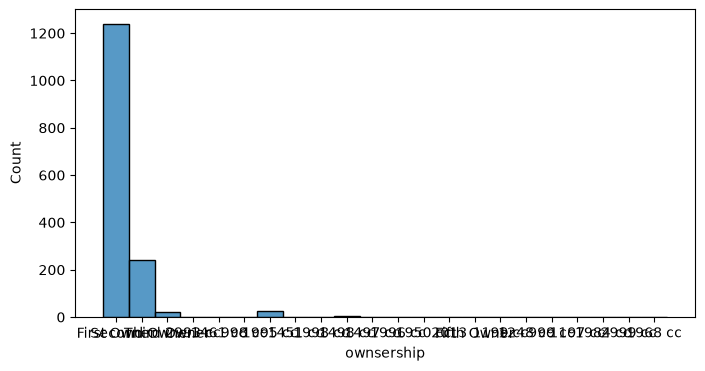

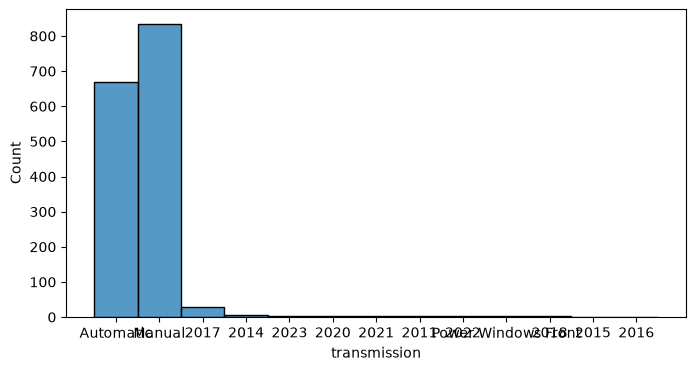

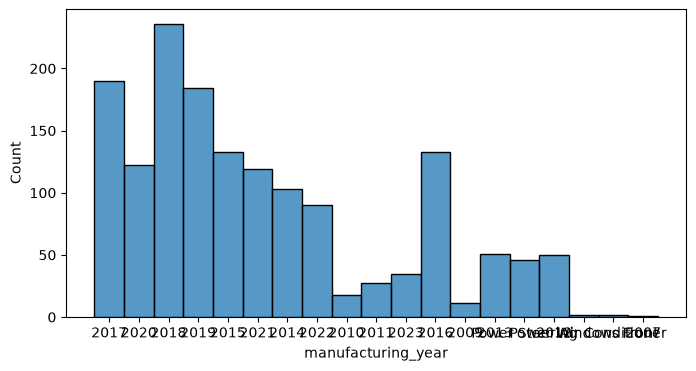

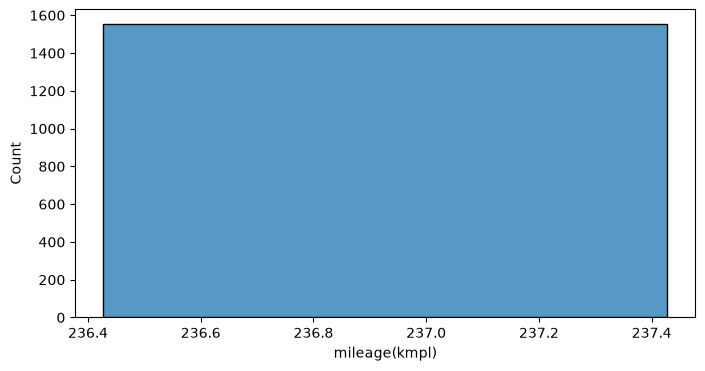

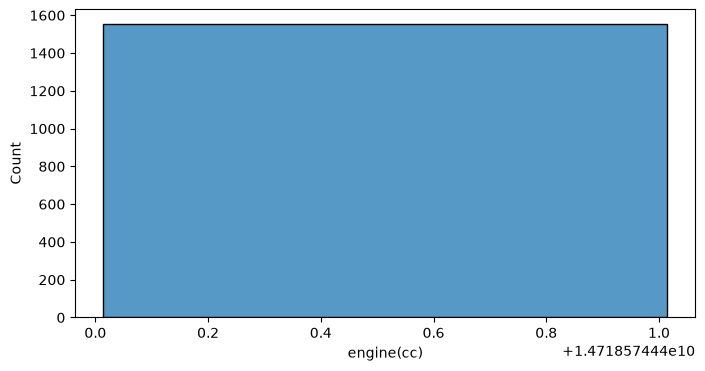

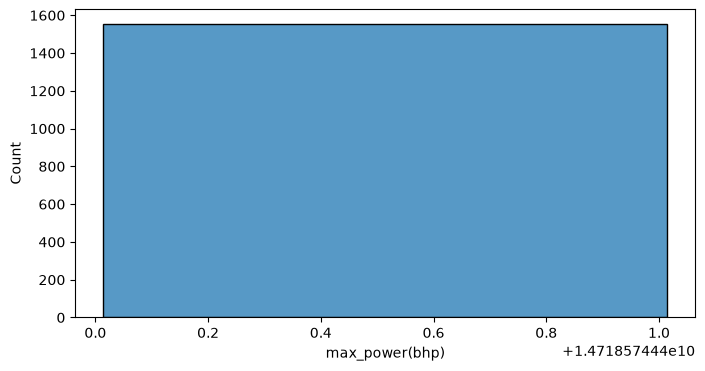

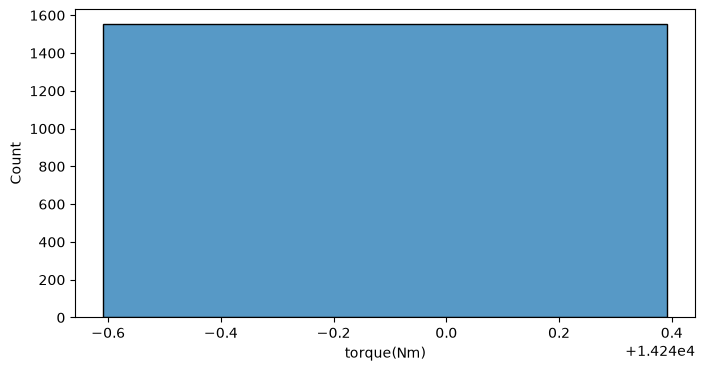

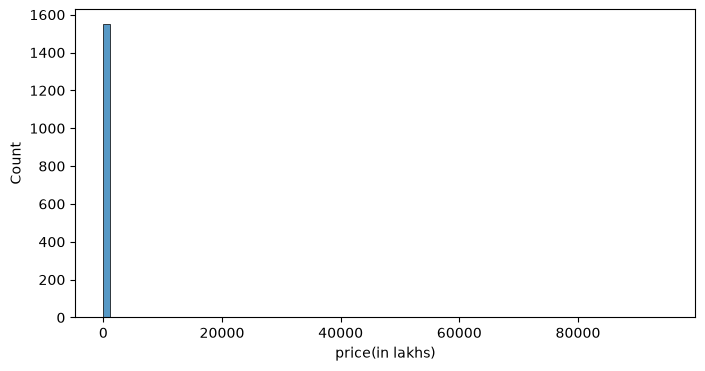

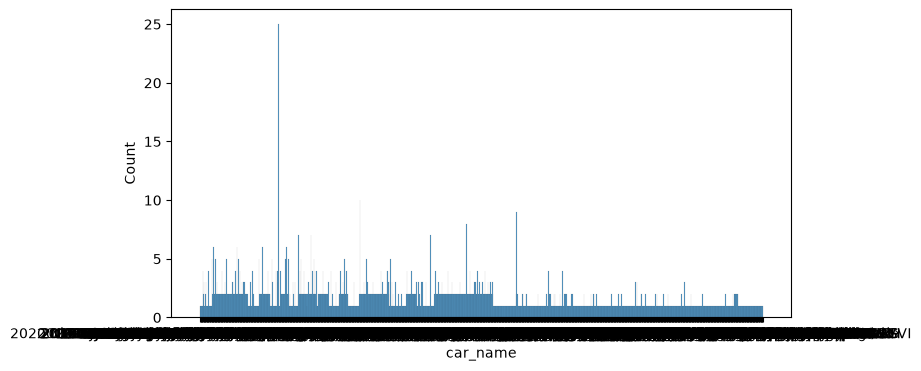

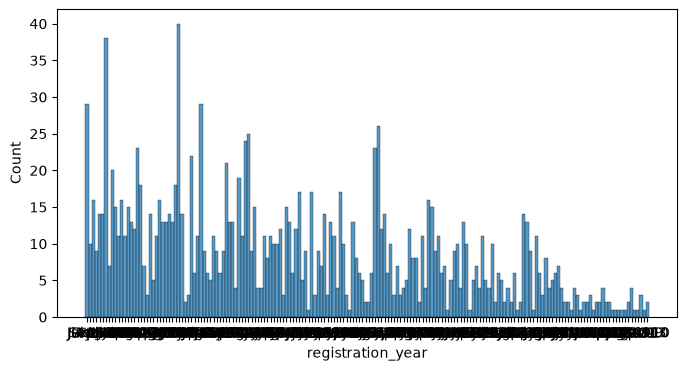

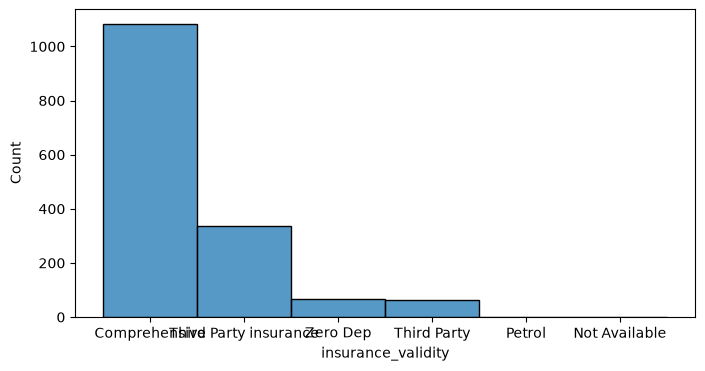

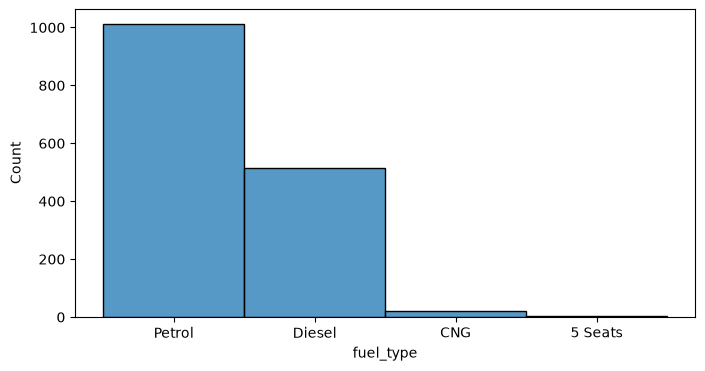

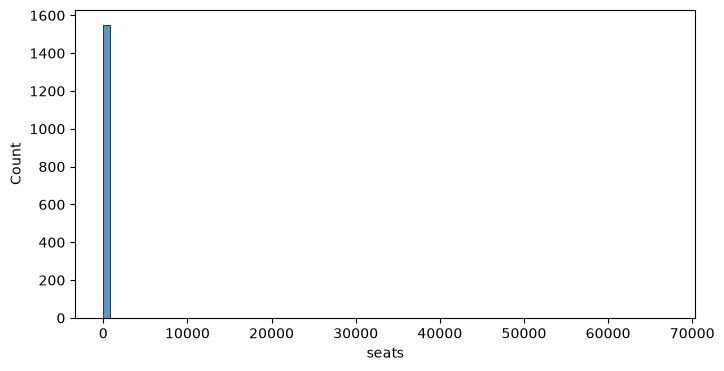

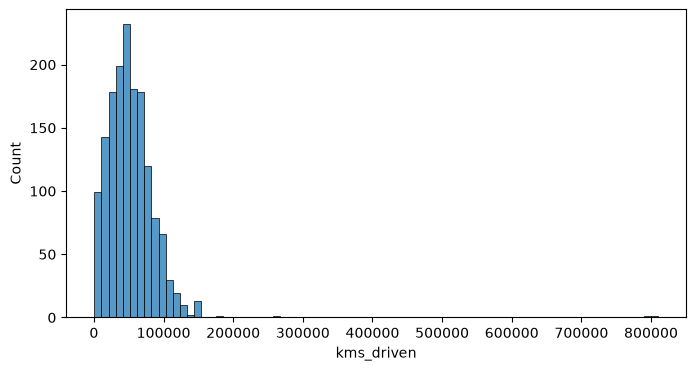

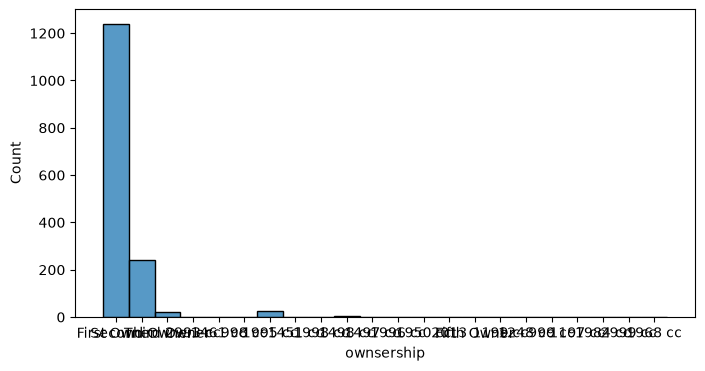

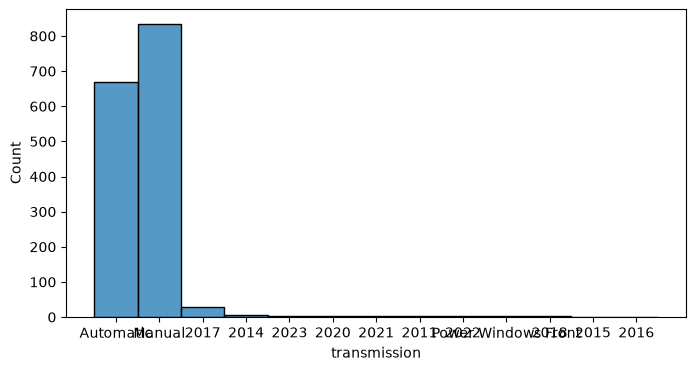

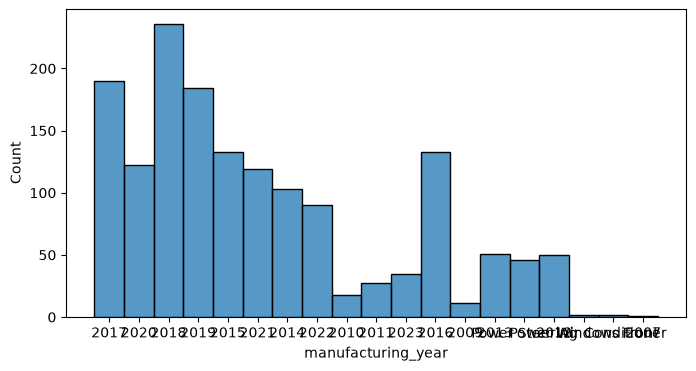

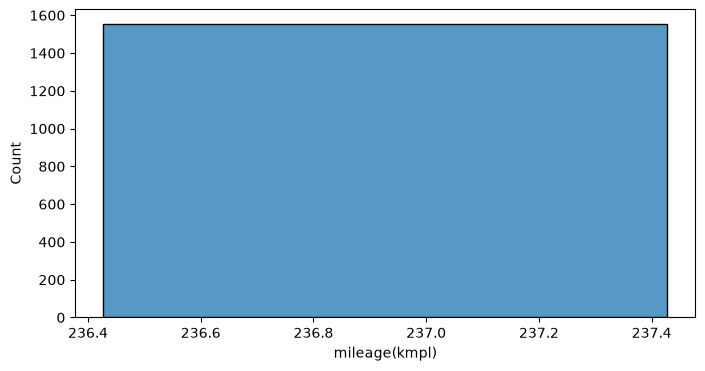

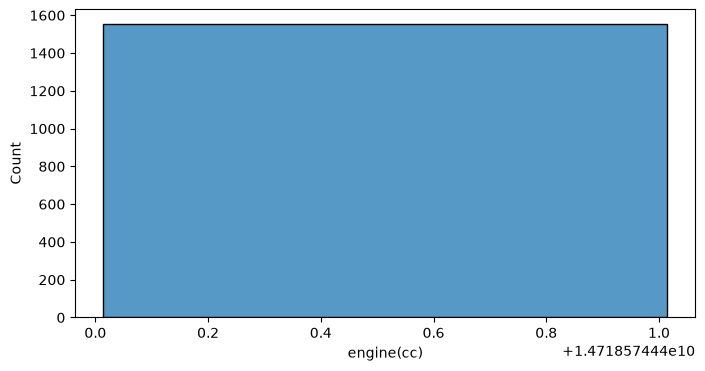

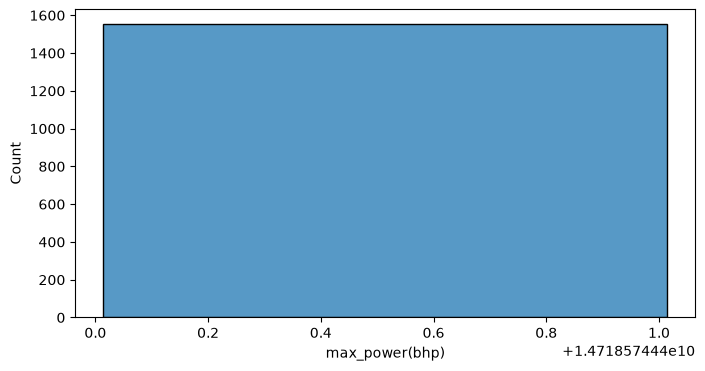

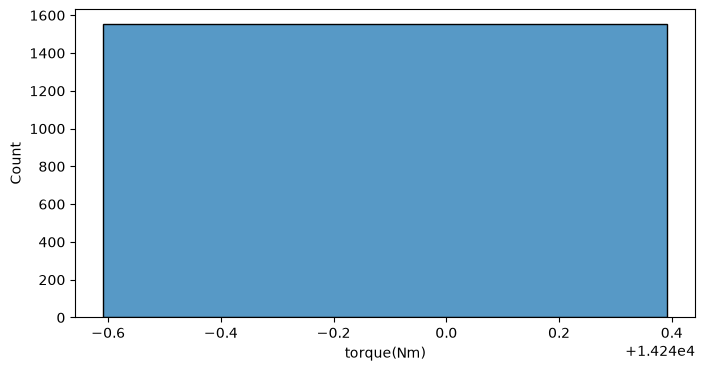

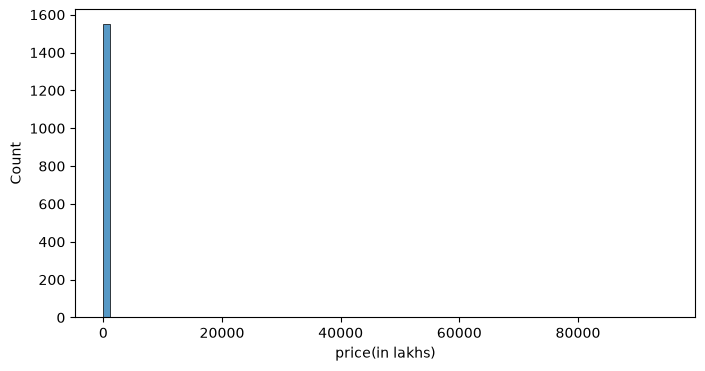

In [ ]:
for col in numaric_col:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col])

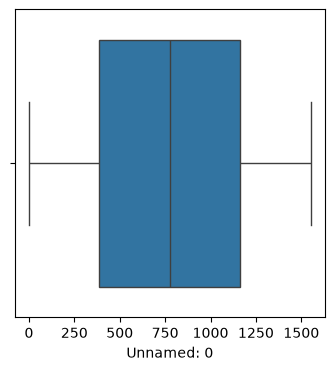

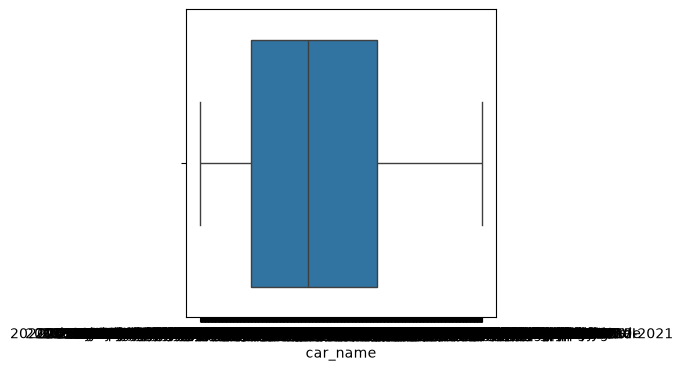

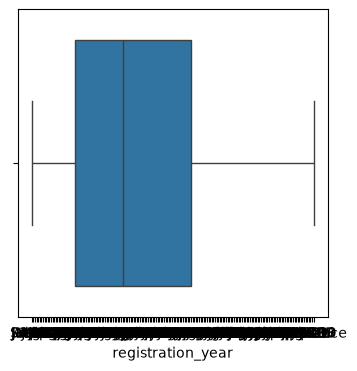

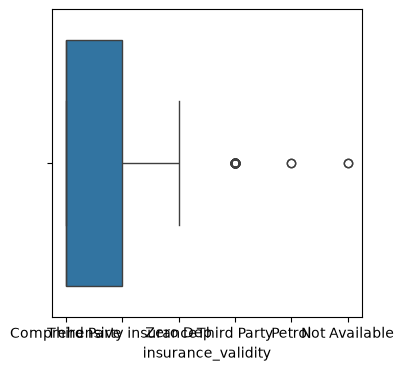

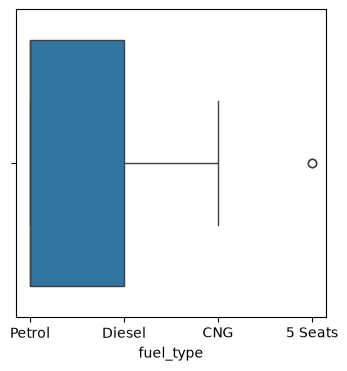

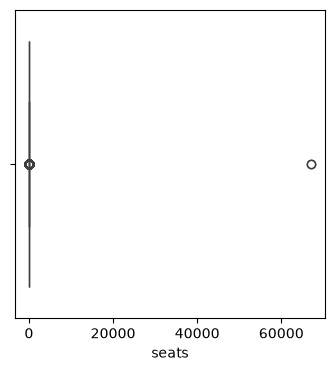

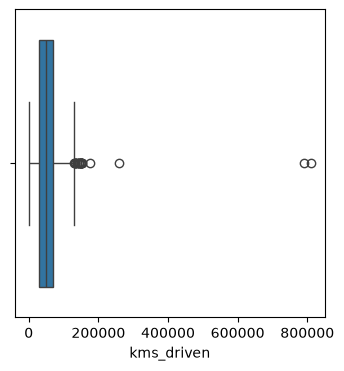

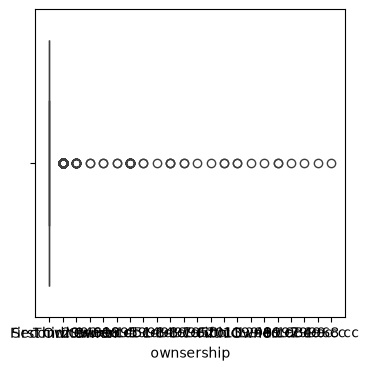

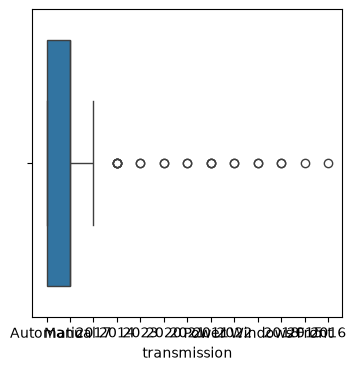

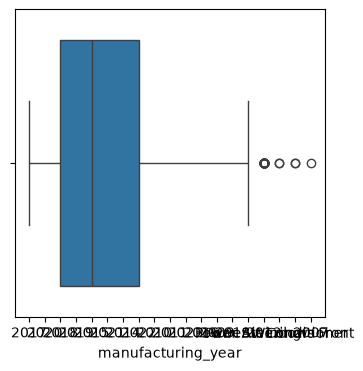

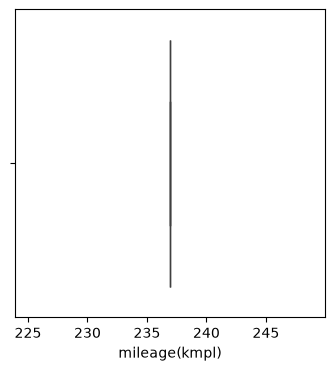

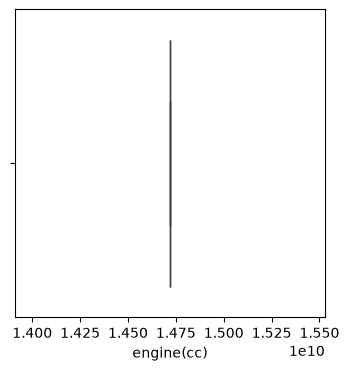

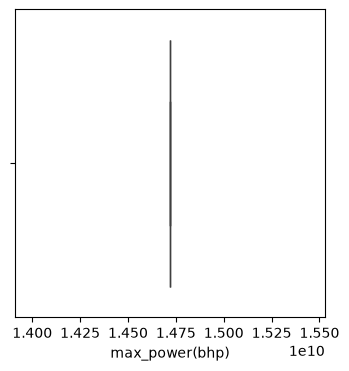

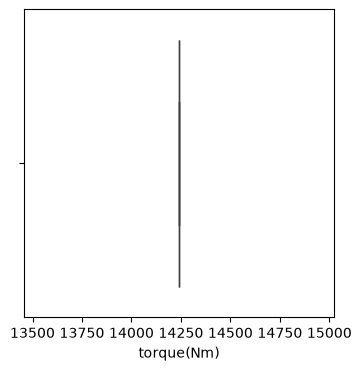

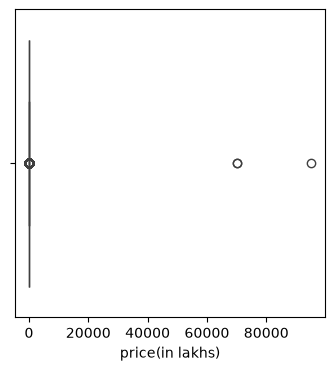

In [ ]:
for col in numaric_col:
    plt.figure(figsize=(4,4))
    sns.boxplot(x = df[col])

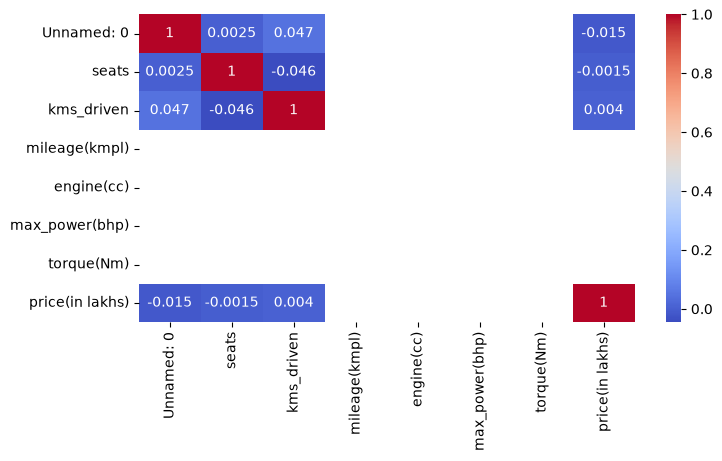

In [ ]:
plt.figure(figsize=(8, 4))
sns.heatmap(df[numaric_col].corr(numeric_only = True),annot=True, cmap="coolwarm")
plt.show()

In [ ]:
df_clean = df.copy()

In [ ]:
df_clean.head()

,Unnamed: 0,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,0,2017 Mercedes-Benz S-Class S400,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,236.927277,1.471857e+10,1.471857e+10,14239.891543,63.75
1,1,2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,236.927277,1.471857e+10,1.471857e+10,14239.891543,8.99
2,2,2018 BMW X1 sDrive 20d xLine,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,236.927277,1.471857e+10,1.471857e+10,14239.891543,23.75
3,3,2019 Kia Seltos GTX Plus,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,236.927277,1.471857e+10,1.471857e+10,14239.891543,13.56
4,4,2019 Skoda Superb LK 1.8 TSI AT,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,236.927277,1.471857e+10,1.471857e+10,14239.891543,24.00


In [ ]:
df_clean = df_clean.drop(columns=["Unnamed: 0",	'car_name','registration_year','insurance_validity', "transmission"])

In [ ]:
df_clean.head()

,fuel_type,seats,kms_driven,ownsership,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,Petrol,5,56000,First Owner,2017,236.927277,1.471857e+10,1.471857e+10,14239.891543,63.75
1,Petrol,5,30615,First Owner,2020,236.927277,1.471857e+10,1.471857e+10,14239.891543,8.99
2,Diesel,5,24000,First Owner,2018,236.927277,1.471857e+10,1.471857e+10,14239.891543,23.75
3,Petrol,5,18378,First Owner,2019,236.927277,1.471857e+10,1.471857e+10,14239.891543,13.56
4,Petrol,5,44900,First Owner,2019,236.927277,1.471857e+10,1.471857e+10,14239.891543,24.00


In [ ]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1553 entries, 0 to 1552
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fuel_type           1553 non-null   str    
 1   seats               1553 non-null   int64  
 2   kms_driven          1553 non-null   int64  
 3   ownsership          1553 non-null   str    
 4   manufacturing_year  1553 non-null   str    
 5   mileage(kmpl)       1553 non-null   float64
 6   engine(cc)          1553 non-null   float64
 7   max_power(bhp)      1553 non-null   float64
 8   torque(Nm)          1553 non-null   float64
 9   price(in lakhs)     1553 non-null   float64
dtypes: float64(5), int64(2), str(3)
memory usage: 121.5 KB


In [ ]:
def convert_to_num(ft):
    if df_clean['fuel_type'] == 'Petrol' :
        return 1
    elif df_clean['fuel_type'] == 'Diesel':
        return 2
    elif df_clean['fuel_type'] == 'CNB':
        return 3
    else:
        return 0

In [ ]:
print(convert_to_num)

<function convert_to_num at 0x000001C15F895D20>


In [ ]:
convert_to_numdf_clean=['fuel_type']

In [ ]:
# df['fuel_type'] = df_clean['fuel_type'] == "Petrol"

In [ ]:
df['fuel_type'].value_counts()

fuel_type
Petrol     1013
Diesel      516
CNG          22
5 Seats       2
Name: count, dtype: int64

In [ ]:
df_clean= df_clean.drop(df_clean[df_clean['fuel_type'].isin(['5 Seats'])].index)


In [ ]:

df_clean['fuel_type'] = df_clean['fuel_type'].map({'Petrol':1, 'Diesel' : 2 , 'CNG' : 3 ,'5 Seats' : 0})

In [ ]:
df_clean['fuel_type'].value_counts()

fuel_type
1    1013
2     516
3      22
Name: count, dtype: int64

In [ ]:
# df_clean['fuel_type'] = pd.get_dummies(df_clean , columns=['fuel_type','transmission','ownsership'] ,drop_first=True)

In [ ]:
df_clean.head()

,fuel_type,seats,kms_driven,ownsership,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,1,5,56000,First Owner,2017,236.927277,1.471857e+10,1.471857e+10,14239.891543,63.75
1,1,5,30615,First Owner,2020,236.927277,1.471857e+10,1.471857e+10,14239.891543,8.99
2,2,5,24000,First Owner,2018,236.927277,1.471857e+10,1.471857e+10,14239.891543,23.75
3,1,5,18378,First Owner,2019,236.927277,1.471857e+10,1.471857e+10,14239.891543,13.56
4,1,5,44900,First Owner,2019,236.927277,1.471857e+10,1.471857e+10,14239.891543,24.00


In [ ]:
df_clean['ownsership'].value_counts()

ownsership
First Owner     1240
Second Owner     240
1995 cc           24
Third Owner       21
1498 cc            3
2993 cc            2
1461 cc            2
998 cc             2
1451 cc            2
1497 cc            2
Fifth Owner        2
999 cc             2
1998 cc            1
1996 cc            1
1950 cc            1
1199 cc            1
1248 cc            1
1197 cc            1
1984 cc            1
2999 cc            1
1968 cc            1
Name: count, dtype: int64

In [ ]:
'2993 cc'
'1461 cc',
'998 cc',
'1451 cc',
'1497 cc',
'999 cc ',
'1998 cc',
'1996 cc',
'1950 cc',
'1199 cc',
'1248 cc',
'1197 cc',
'1984 cc',
'2999 cc',
'1968 cc',

('1968 cc',)

In [ ]:
df_clean= df_clean.drop(df_clean[df_clean['ownsership'].isin(['1995 cc','2993 cc','999 cc','1498 cc','1461 cc','998 cc','1451 cc','1497 cc','999 cc ','1998 cc','1996 cc','1950 cc','1199 cc','1248 cc','1197 cc','1984 cc','2999 cc','1968 cc',])].index)


In [ ]:
df_clean['ownsership'].value_counts()

ownsership
First Owner     1240
Second Owner     240
Third Owner       21
Fifth Owner        2
Name: count, dtype: int64

In [ ]:
df_clean['ownsership'] = df_clean['ownsership'].map({'First Owner':1, 'Second Owner' : 2 , 'Third Owner' : 3 ,'Fifth Owner' : 5})

In [ ]:
df_clean.head()

,fuel_type,seats,kms_driven,ownsership,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,1,5,56000,1,2017,236.927277,1.471857e+10,1.471857e+10,14239.891543,63.75
1,1,5,30615,1,2020,236.927277,1.471857e+10,1.471857e+10,14239.891543,8.99
2,2,5,24000,1,2018,236.927277,1.471857e+10,1.471857e+10,14239.891543,23.75
3,1,5,18378,1,2019,236.927277,1.471857e+10,1.471857e+10,14239.891543,13.56
4,1,5,44900,1,2019,236.927277,1.471857e+10,1.471857e+10,14239.891543,24.00


In [ ]:
df_clean.columns

Index(['fuel_type', 'seats', 'kms_driven', 'ownsership', 'manufacturing_year',
       'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)',
       'price(in lakhs)'],
      dtype='str')

In [ ]:
feature_df = ['fuel_type', 'seats', 'kms_driven', 'ownsership', 'manufacturing_year',
    'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)',
    'price(in lakhs)']

In [ ]:
df_clean.head()

,fuel_type,seats,kms_driven,ownsership,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,1,5,56000,1,2017,236.927277,1.471857e+10,1.471857e+10,14239.891543,63.75
1,1,5,30615,1,2020,236.927277,1.471857e+10,1.471857e+10,14239.891543,8.99
2,2,5,24000,1,2018,236.927277,1.471857e+10,1.471857e+10,14239.891543,23.75
3,1,5,18378,1,2019,236.927277,1.471857e+10,1.471857e+10,14239.891543,13.56
4,1,5,44900,1,2019,236.927277,1.471857e+10,1.471857e+10,14239.891543,24.00


In [ ]:
df_clean['manufacturing_year']= df_clean['manufacturing_year'].astype(int)

In [ ]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [ ]:
df_clean['Car_age'] = 2026 - df_clean['manufacturing_year']

In [ ]:
col =['kms_driven','seats','manufacturing_year','mileage(kmpl)','engine(cc)','max_power(bhp)','torque(Nm)','price(in lakhs)']

scalar = StandardScaler()
df_clean[col] =scalar.fit_transform (df_clean[col])

In [ ]:
scalar.mean_

array([5.31884804e+04, 5.20558882e+00, 2.01737126e+03, 2.36927277e+02,
       1.47185744e+10, 1.47185744e+10, 1.42398915e+04, 1.71102468e+02])

In [ ]:
scalar.scale_

array([4.03533263e+04, 6.35746560e-01, 3.00729191e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 3.53499947e+03])

In [ ]:
df_clean.head()

,fuel_type,seats,kms_driven,ownsership,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs),Car_age
0,1,-0.323382,0.069673,1,-0.123452,-8.526513e-14,0.000004,0.000004,1.818989e-12,-0.030368,9
1,1,-0.323382,-0.559396,1,0.874123,-8.526513e-14,0.000004,0.000004,1.818989e-12,-0.045859,6
2,2,-0.323382,-0.723323,1,0.209073,-8.526513e-14,0.000004,0.000004,1.818989e-12,-0.041684,8
3,1,-0.323382,-0.862642,1,0.541598,-8.526513e-14,0.000004,0.000004,1.818989e-12,-0.044566,7
4,1,-0.323382,-0.205398,1,0.541598,-8.526513e-14,0.000004,0.000004,1.818989e-12,-0.041613,7


In [ ]:
df_clean.columns

Index(['fuel_type', 'seats', 'kms_driven', 'ownsership', 'manufacturing_year',
       'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)',
       'price(in lakhs)', 'Car_age'],
      dtype='str')

In [ ]:
from scipy.stats import pearsonr

In [ ]:
selected_feature = ['fuel_type', 'seats', 'kms_driven', 'ownsership', 'manufacturing_year',
    'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)','Car_age',
    'price(in lakhs)']

In [ ]:
corr= {
    feature : pearsonr(df_clean[feature], df_clean['price(in lakhs)'])
    for feature in selected_feature
}
corr_df = pd.DataFrame(list(corr.items()), columns=['Feature', 'pearson Correlation'])

corr_df = corr_df.sort_values(by='pearson Correlation', ascending=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_16952\41430024.py:2: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  feature : pearsonr(df_clean[feature], df_clean['price(in lakhs)'])


In [ ]:
corr_df['Feature']

3             ownsership
2             kms_driven
1                  seats
0              fuel_type
4     manufacturing_year
5          mileage(kmpl)
6             engine(cc)
7         max_power(bhp)
8             torque(Nm)
10       price(in lakhs)
9                Car_age
Name: Feature, dtype: str

In [ ]:
corr_df

,Feature,pearson Correlation
3,ownsership,"(0.11989866399263284, 3.1428978880083805e-06)"
2,kms_driven,"(0.0036410799765111616, 0.8878364517913934)"
1,seats,"(-0.013551870804453199, 0.5996017593298761)"
0,fuel_type,"(-0.029632570007129756, 0.25092401973427947)"
4,manufacturing_year,"(-0.10376636904981248, 5.5680061226321954e-05)"
5,mileage(kmpl),"(nan, nan)"
6,engine(cc),"(nan, nan)"
7,max_power(bhp),"(nan, nan)"
8,torque(Nm),"(nan, nan)"
10,price(in lakhs),"(1.0, 0.0)"


In [ ]:
df_clean.head()

,fuel_type,seats,kms_driven,ownsership,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs),Car_age
0,1,-0.323382,0.069673,1,-0.123452,-8.526513e-14,0.000004,0.000004,1.818989e-12,-0.030368,9
1,1,-0.323382,-0.559396,1,0.874123,-8.526513e-14,0.000004,0.000004,1.818989e-12,-0.045859,6
2,2,-0.323382,-0.723323,1,0.209073,-8.526513e-14,0.000004,0.000004,1.818989e-12,-0.041684,8
3,1,-0.323382,-0.862642,1,0.541598,-8.526513e-14,0.000004,0.000004,1.818989e-12,-0.044566,7
4,1,-0.323382,-0.205398,1,0.541598,-8.526513e-14,0.000004,0.000004,1.818989e-12,-0.041613,7


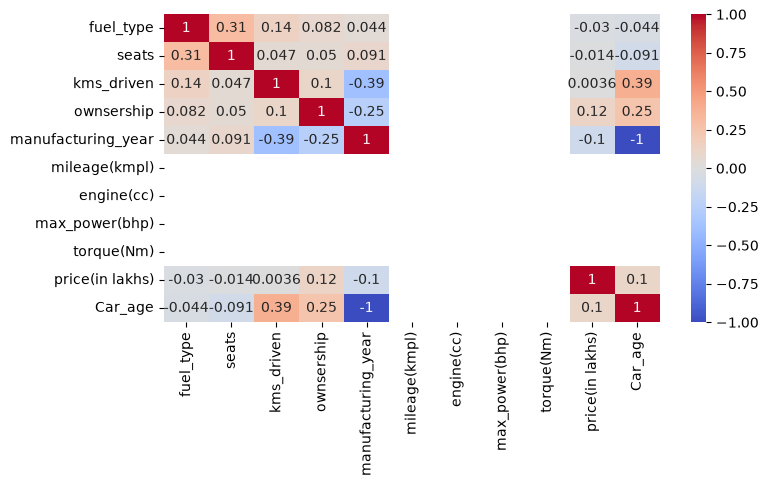

In [ ]:
plt.figure(figsize=(8, 4))
sns.heatmap(df_clean.corr(numeric_only = True),annot=True, cmap="coolwarm")
plt.show()

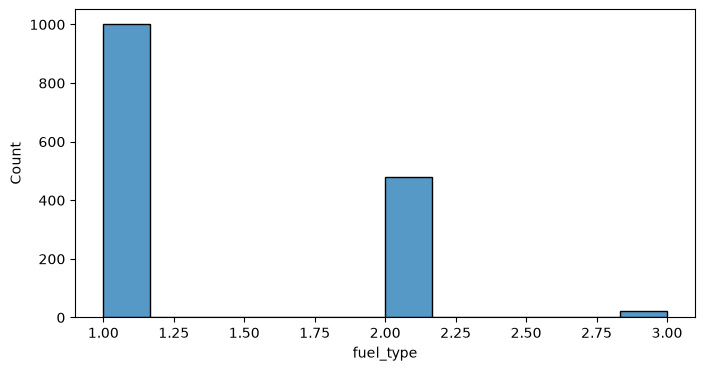

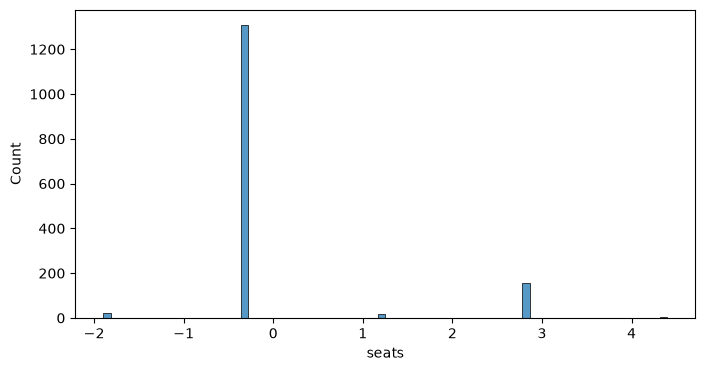

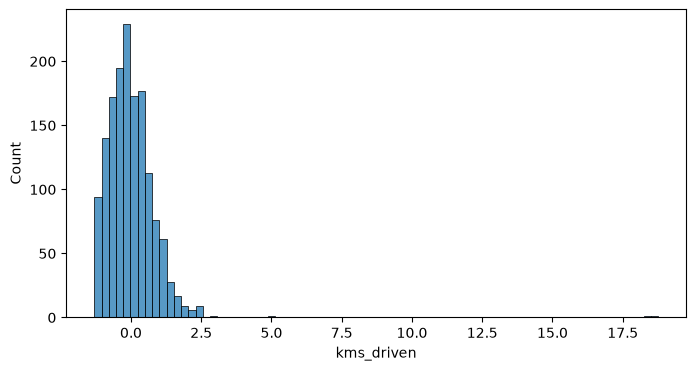

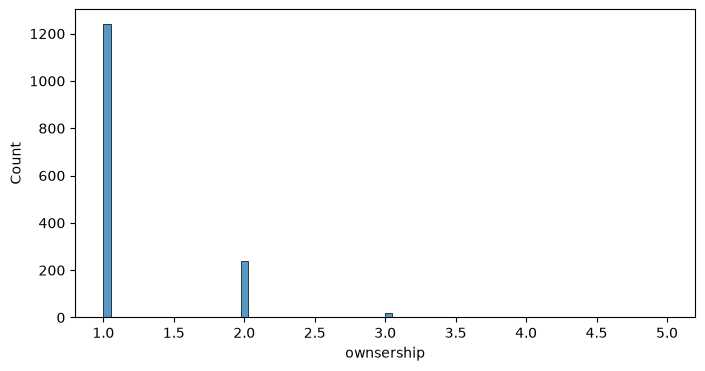

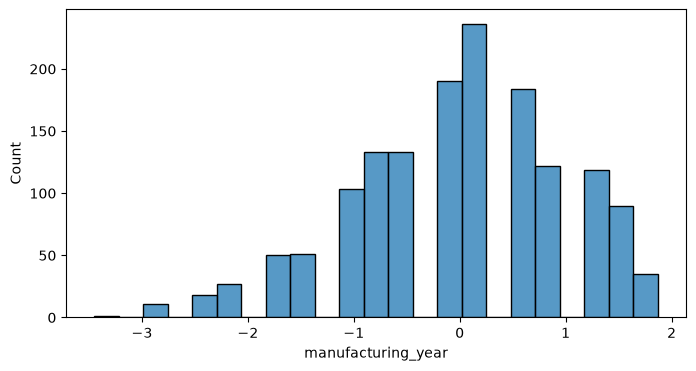

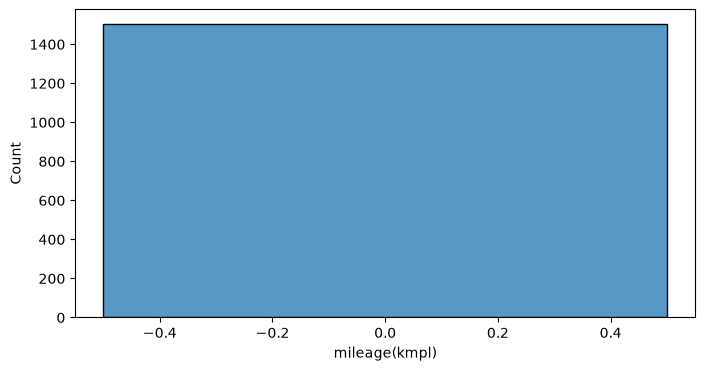

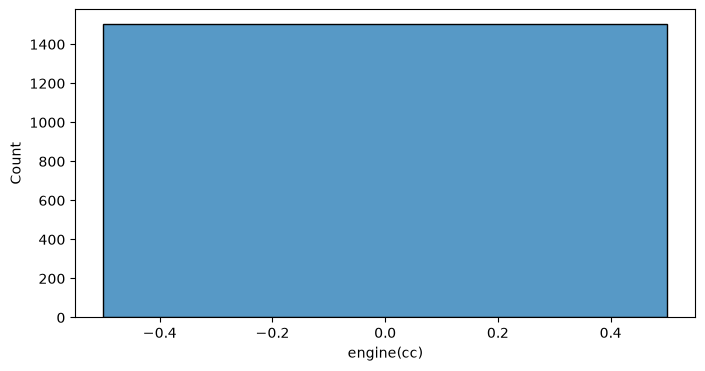

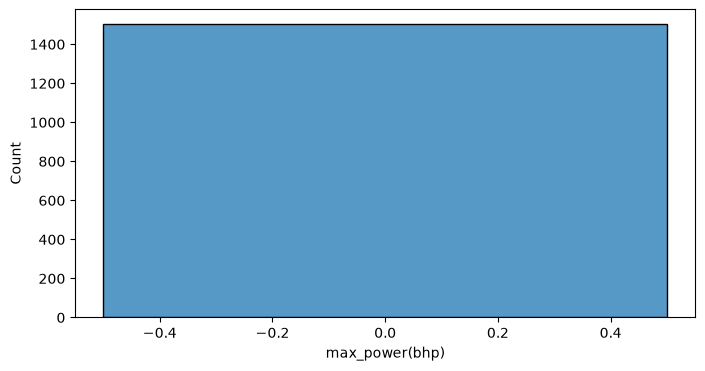

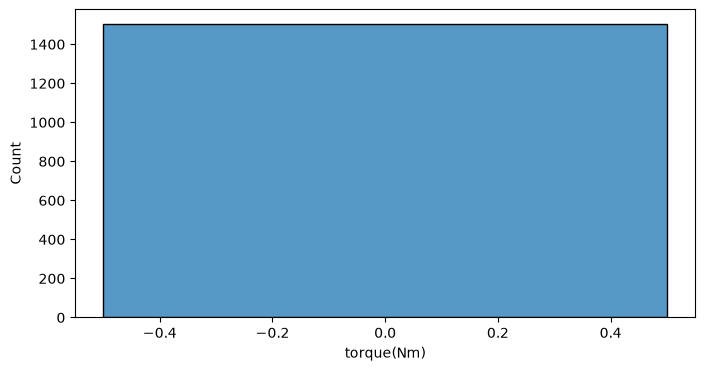

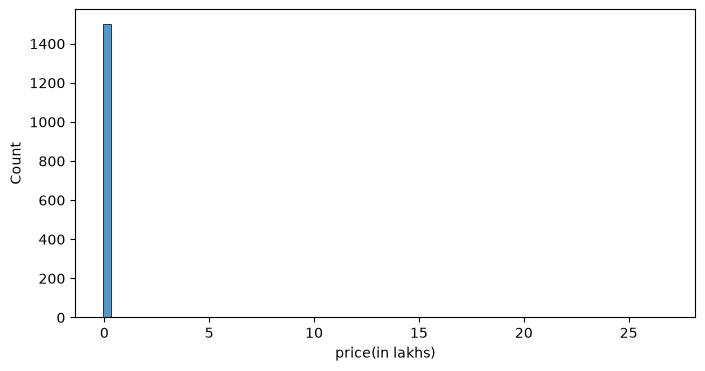

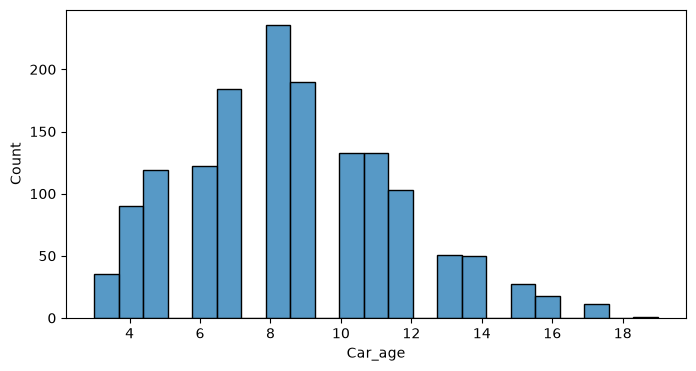

In [ ]:
for col in df_clean:
    plt.figure(figsize=(8,4))
    sns.histplot(df_clean[col])

In [ ]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1503 entries, 0 to 1552
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fuel_type           1503 non-null   int64  
 1   seats               1503 non-null   float64
 2   kms_driven          1503 non-null   float64
 3   ownsership          1503 non-null   int64  
 4   manufacturing_year  1503 non-null   float64
 5   mileage(kmpl)       1503 non-null   float64
 6   engine(cc)          1503 non-null   float64
 7   max_power(bhp)      1503 non-null   float64
 8   torque(Nm)          1503 non-null   float64
 9   price(in lakhs)     1503 non-null   float64
 10  Car_age             1503 non-null   int64  
dtypes: float64(8), int64(3)
memory usage: 140.9 KB


In [ ]:
df_clean.describe()

,fuel_type,seats,kms_driven,ownsership,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs),Car_age
count,1503.000000,1.503000e+03,1.503000e+03,1503.000000,1.503000e+03,1.503000e+03,1503.000000,1503.000000,1.503000e+03,1.503000e+03,1503.000000
mean,1.348636,1.890999e-16,-3.781997e-17,1.192947,1.311408e-14,-8.526513e-14,0.000004,0.000004,1.818989e-12,3.545622e-18,8.628743
std,0.506492,1.000333e+00,1.000333e+00,0.446949,1.000333e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000333e+00,3.008293
min,1.000000,-1.896336e+00,-1.302705e+00,1.000000,-3.448703e+00,-8.526513e-14,0.000004,0.000004,1.818989e-12,-4.811952e-02,3.000000
25%,1.000000,-3.233817e-01,-5.746362e-01,1.000000,-7.885026e-01,-8.526513e-14,0.000004,0.000004,1.818989e-12,-4.709547e-02,7.000000
50%,1.000000,-3.233817e-01,-8.907519e-02,1.000000,2.090727e-01,-8.526513e-14,0.000004,0.000004,1.818989e-12,-4.643635e-02,8.000000
75%,2.000000,-3.233817e-01,4.166080e-01,1.000000,5.415977e-01,-8.526513e-14,0.000004,0.000004,1.818989e-12,-4.387624e-02,11.000000
max,3.000000,4.395480e+00,1.875463e+01,5.000000,1.871698e+00,-8.526513e-14,0.000004,0.000004,1.818989e-12,2.682572e+01,19.000000


In [ ]:
df_clean.isnull().sum()

fuel_type             0
seats                 0
kms_driven            0
ownsership            0
manufacturing_year    0
mileage(kmpl)         0
engine(cc)            0
max_power(bhp)        0
torque(Nm)            0
price(in lakhs)       0
Car_age               0
dtype: int64

In [ ]:
df_clean.columns

Index(['fuel_type', 'seats', 'kms_driven', 'ownsership', 'manufacturing_year',
       'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)', 'torque(Nm)',
       'price(in lakhs)', 'Car_age'],
      dtype='str')

In [ ]:
x = df_clean[['seats', 'kms_driven', 'ownsership', 'manufacturing_year','max_power(bhp)']]
y = df_clean['price(in lakhs)']

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x ,y , test_size=0.2 , random_state=42)

In [ ]:
print("x_train" , x_train.shape)
print("y_train" , y_train.shape)
print("x_test" , x_test.shape)
print("y_test" , y_test.shape)


x_train (1202, 6)
y_train (1202,)
x_test (301, 6)
y_test (301,)


In [ ]:
model = LinearRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)


In [ ]:
y_pred

array([-6.68481909e-02, -6.09866843e-02,  2.63066845e-01,  4.41304154e-02,
        1.99708031e-01, -1.59275705e-02,  3.68265282e-02,  4.75695660e-02,
        3.02367334e-01, -2.28248537e-01,  1.99708031e-01,  3.62681348e-01,
        3.17743406e-01, -7.70335429e-02, -1.74257139e-01, -2.12076176e-01,
        2.87323455e-01, -1.91543220e-02,  1.36259950e-01, -3.96356784e-02,
        2.26589429e-01, -1.06682440e-01, -9.52186384e-02, -9.26055081e-02,
        2.02063098e-01,  4.22712589e-02, -3.96356784e-02,  7.17012422e-02,
        2.35030856e-01, -9.12583903e-02, -3.02952500e-02,  3.18278609e-02,
        2.19893144e-01, -9.40800151e-02,  6.14534706e-03,  2.73884543e-01,
       -1.45831004e-01, -1.27227303e-01, -1.20424701e-01, -4.76885516e-02,
       -1.23657801e-01,  9.09169202e-01, -6.13063750e-02, -8.08991491e-02,
       -1.52018912e-01, -1.60086322e-01,  2.39393608e-01, -1.07445733e-01,
       -1.99202038e-01, -1.36433919e-01,  4.14838623e-02,  1.72432721e-01,
       -1.00493793e-01, -

In [ ]:
print("r2 :",r2_score(y_test,y_pred))

r2 : -2030.4718081819885


In [ ]:
print("MAE : ", mean_absolute_error(y_test, y_pred))
print("MSE : ", mean_squared_error(y_test, y_pred))
print("R2  : ", r2_score(y_test, y_pred))

MAE :  0.15577386798824985
MSE :  0.05060636179592782
R2  :  -2030.4718081819885


In [ ]:
print("x_train" , x_train.shape)
print("y_train" , y_train.shape)
print("x" , x.shape)
print("y" , y.shape)

x_train (1202, 6)
y_train (1202,)
x (1503, 6)
y (1503,)


In [ ]:
print('\ny_test')
print(y_test[:10])

print('\ny_pred')
print(y_pred[:10])


y_test
51     -0.046507
1514   -0.046439
187    -0.047888
1040   -0.047506
784    -0.045953
1073   -0.046479
965    -0.045964
422    -0.033692
627    -0.042462
617    -0.042745
Name: price(in lakhs), dtype: float64

y_pred
[-0.06684819 -0.06098668  0.26306684  0.04413042  0.19970803 -0.01592757
  0.03682653  0.04756957  0.30236733 -0.22824854]


In [ ]:
print("Target mean : " , y.mean())
print("target std :",y.std())

print("predicition mean: " , y_pred.mean())
print("predicition std : " , y_pred.std())

Target mean :  3.545622433932635e-18
target std : 1.0003328340914261
predicition mean:  0.03868525631973265
predicition std :  0.20848899702466908


In [ ]:
print("Actual min/max :",y_test.min(),y_test.max())
print("predicition min/max :",y_pred.min(),y_pred.max())

Actual min/max : -0.04811951742692594 -0.02039674095994637
predicition min/max : -1.3934366042207145 0.9091692022207951
